# Probability Foundations — Part 4
## Computer Exercises: Statistical and Likelihood Inference

This notebook complements the main Chapter 5–6 learning notebook with **computational practice**.

It is based on the computer exercises supplied in the textbook, but it is intentionally selective. Exercises that reinforce the main learning goals were kept or adapted, while lower-priority or repetitive exercises were omitted. A few additional experiments were added because they connect the statistical ideas more directly to later machine-learning work.

### Main goals

1. Visualize likelihood functions and recover MLEs numerically.
2. Compare likelihood and log-likelihood.
3. Study estimator bias, variance, and MSE by simulation.
4. Distinguish population standard deviation from estimator standard error.
5. Empirically study confidence-interval coverage.
6. Explore power as a function of sample size.
7. Perform sample-size planning from a target margin of error.
8. Use bootstrapping to approximate sampling distributions and standard errors.
9. Compare the robustness of the mean and median.
10. Construct and compare classical and bootstrap confidence intervals.

## Setup

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar
from scipy.stats import norm, t

rng = np.random.default_rng(42)

---

# 1. Likelihood landscapes and numerical MLEs

The textbook exercises 6.2.17 and 6.2.18 ask us to study two likelihood functions:

$$
L_1(\theta)
=
\exp\left(-\frac{(\theta-1)^2}{2}\right)
+
3\exp\left(-\frac{(\theta-2)^2}{2}\right),
$$

and

$$
L_2(\theta)
=
\exp\left(-\frac{(\theta-1)^2}{2}\right)
+
3\exp\left(-\frac{(\theta-5)^2}{2}\right).
$$

We first approximate the MLE by evaluating each likelihood on 1000 equally spaced points in $[-10,10]$, following the textbook.

In [2]:
theta = np.linspace(-10, 10, 1000)

def L1(theta):
    return np.exp(-0.5 * (theta - 1)**2) + 3 * np.exp(-0.5 * (theta - 2)**2)

def L2(theta):
    return np.exp(-0.5 * (theta - 1)**2) + 3 * np.exp(-0.5 * (theta - 5)**2)

L1_vals = L1(theta)
L2_vals = L2(theta)

theta_hat_1_grid = theta[np.argmax(L1_vals)]
theta_hat_2_grid = theta[np.argmax(L2_vals)]

print(f"Grid MLE for L1: theta ≈ {theta_hat_1_grid:.4f}")
print(f"Grid MLE for L2: theta ≈ {theta_hat_2_grid:.4f}")

Grid MLE for L1: theta ≈ 1.8118
Grid MLE for L2: theta ≈ 4.9950


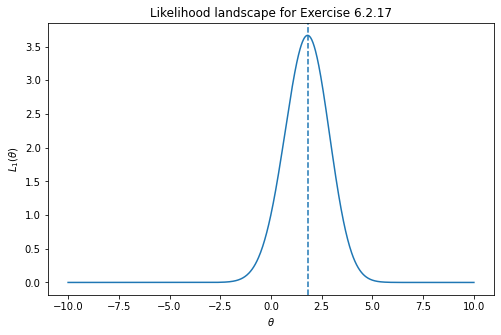

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(theta, L1_vals)
plt.axvline(theta_hat_1_grid, linestyle="--")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$L_1(\theta)$")
plt.title("Likelihood landscape for Exercise 6.2.17")
plt.show()

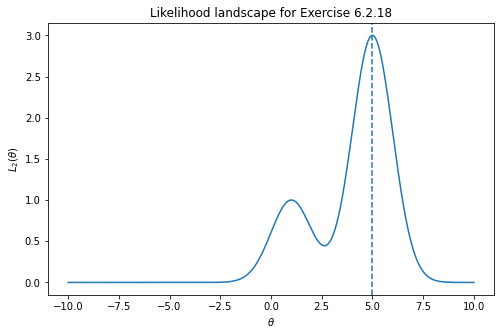

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(theta, L2_vals)
plt.axvline(theta_hat_2_grid, linestyle="--")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$L_2(\theta)$")
plt.title("Likelihood landscape for Exercise 6.2.18")
plt.show()

### Observation

The first likelihood has strongly overlapping components, producing one dominant peak. The second has well-separated components and a more complicated shape.

$$
\boxed{
\text{A likelihood function does not have to be symmetric or unimodal.}
}
$$

This is one reason numerical optimization and visualization are useful before assuming that a stationary point is the global MLE.

### 1.1 Refine the grid estimate with numerical optimization

We can maximize a function numerically by minimizing its negative.

In [5]:
res1 = minimize_scalar(lambda x: -L1(x), bounds=(-10, 10), method="bounded")
res2 = minimize_scalar(lambda x: -L2(x), bounds=(-10, 10), method="bounded")

print(f"Optimized MLE for L1: theta ≈ {res1.x:.6f}")
print(f"Optimized MLE for L2: theta ≈ {res2.x:.6f}")

Optimized MLE for L1: theta ≈ 1.802334
Optimized MLE for L2: theta ≈ 4.999552


The grid search and optimizer should give nearly identical results, with the optimizer giving a more precise numerical answer.

---

# 2. Likelihood versus log-likelihood

For i.i.d. observations,

$$
L(\theta\mid x_{1:n})
=
\prod_{i=1}^n f_\theta(x_i),
$$

while

$$
\ell(\theta\mid x_{1:n})
=
\sum_{i=1}^n \log f_\theta(x_i).
$$

Because $\log$ is strictly increasing,

$$
\arg\max_\theta L(\theta)
=
\arg\max_\theta \ell(\theta).
$$

This is directly relevant to machine learning, where we often minimize the **negative log-likelihood**.

In [6]:
x = np.array([1, 1, 0, 1, 1, 0, 1, 0, 1, 1])
n = len(x)
k = x.sum()

theta_grid = np.linspace(0.001, 0.999, 1000)

likelihood = theta_grid**k * (1 - theta_grid)**(n - k)
log_likelihood = k * np.log(theta_grid) + (n - k) * np.log(1 - theta_grid)

theta_hat_L = theta_grid[np.argmax(likelihood)]
theta_hat_logL = theta_grid[np.argmax(log_likelihood)]

print(f"MLE from likelihood:     {theta_hat_L:.4f}")
print(f"MLE from log-likelihood: {theta_hat_logL:.4f}")
print(f"Analytic MLE k/n:        {k/n:.4f}")

MLE from likelihood:     0.7003
MLE from log-likelihood: 0.7003
Analytic MLE k/n:        0.7000


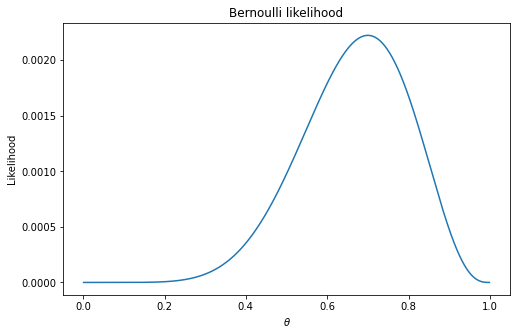

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(theta_grid, likelihood)
plt.xlabel(r"$\theta$")
plt.ylabel("Likelihood")
plt.title("Bernoulli likelihood")
plt.show()

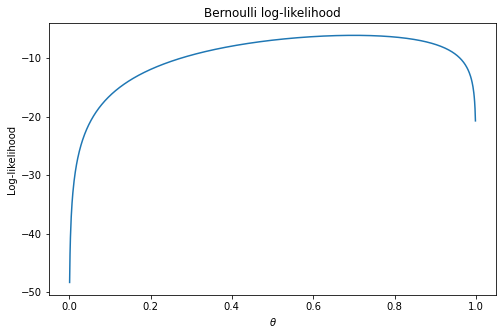

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(theta_grid, log_likelihood)
plt.xlabel(r"$\theta$")
plt.ylabel("Log-likelihood")
plt.title("Bernoulli log-likelihood")
plt.show()

### Observation

The two curves have very different vertical scales, but they are maximized at the same $\theta$.

---

# 3. Normal variance: MLE versus unbiased estimator

For a Normal sample,

$$
X_i\sim N(\mu,\sigma^2),
$$

the MLE of the variance is

$$
\hat\sigma^2_{\mathrm{MLE}}
=
\frac{1}{n}
\sum_{i=1}^n (X_i-\bar X)^2,
$$

whereas the usual unbiased sample variance is

$$
S^2
=
\frac{1}{n-1}
\sum_{i=1}^n (X_i-\bar X)^2.
$$

We estimate their bias and MSE by simulation.

In [9]:
mu = 0.0
sigma = 2.0
true_var = sigma**2
n = 8
num_trials = 100_000

samples = rng.normal(mu, sigma, size=(num_trials, n))
means = samples.mean(axis=1)
ss = ((samples - means[:, None])**2).sum(axis=1)

var_mle = ss / n
var_unbiased = ss / (n - 1)

def summarize(estimates, truth):
    bias = estimates.mean() - truth
    variance = estimates.var(ddof=0)
    mse = np.mean((estimates - truth)**2)
    return bias, variance, mse

mle_stats = summarize(var_mle, true_var)
unbiased_stats = summarize(var_unbiased, true_var)

print("Estimator                  Bias       Variance       MSE")
print(f"MLE variance             {mle_stats[0]: .5f}   {mle_stats[1]: .5f}   {mle_stats[2]: .5f}")
print(f"Unbiased sample variance {unbiased_stats[0]: .5f}   {unbiased_stats[1]: .5f}   {unbiased_stats[2]: .5f}")

Estimator                  Bias       Variance       MSE
MLE variance             -0.49395    3.56465    3.80864
Unbiased sample variance  0.00691    4.65587    4.65592


### Observation

The MLE is biased downward for finite $n$, while $S^2$ is unbiased.

However, unbiasedness is not the only criterion for estimator quality:

$$
\operatorname{MSE}(T)
=
\operatorname{Var}(T)
+
\operatorname{Bias}(T)^2.
$$

---

# 4. Standard deviation versus standard error

The population standard deviation describes spread of individual observations:

$$
\operatorname{SD}(X)=\sigma.
$$

For the sample mean,

$$
\operatorname{SE}(\bar X)
=
\frac{\sigma}{\sqrt n}.
$$

We verify the $1/\sqrt n$ behavior empirically.

In [10]:
mu = 10.0
sigma = 4.0
num_trials = 50_000
sample_sizes = np.array([5, 10, 20, 50, 100, 200])

empirical_se = []
theoretical_se = []

for n in sample_sizes:
    samples = rng.normal(mu, sigma, size=(num_trials, n))
    sample_means = samples.mean(axis=1)
    empirical_se.append(sample_means.std(ddof=0))
    theoretical_se.append(sigma / np.sqrt(n))

for n, emp, theo in zip(sample_sizes, empirical_se, theoretical_se):
    print(f"n={n:3d} | empirical SE={emp:.4f} | theoretical SE={theo:.4f}")

n=  5 | empirical SE=1.7793 | theoretical SE=1.7889
n= 10 | empirical SE=1.2679 | theoretical SE=1.2649
n= 20 | empirical SE=0.8928 | theoretical SE=0.8944
n= 50 | empirical SE=0.5670 | theoretical SE=0.5657
n=100 | empirical SE=0.4013 | theoretical SE=0.4000
n=200 | empirical SE=0.2831 | theoretical SE=0.2828


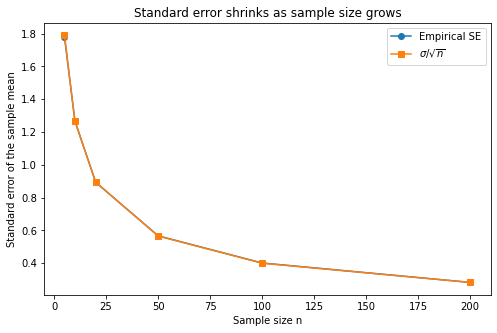

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, empirical_se, marker="o", label="Empirical SE")
plt.plot(sample_sizes, theoretical_se, marker="s", label=r"$\sigma/\sqrt{n}$")
plt.xlabel("Sample size n")
plt.ylabel("Standard error of the sample mean")
plt.title("Standard error shrinks as sample size grows")
plt.legend()
plt.show()

The population SD remains fixed, but the sampling distribution of $\bar X$ becomes narrower as $n$ increases.

---

# 5. Confidence-interval coverage

The textbook exercises include simulations that ask whether nominal confidence intervals achieve their advertised coverage.

## 5.1 Bernoulli Wald interval coverage

For a Bernoulli parameter $\theta$, an approximate 95% interval is

$$
\bar X
\pm
1.96
\sqrt{
\frac{\bar X(1-\bar X)}{n}
}.
$$

For small $n$, this approximation can perform poorly.

In [12]:
theta_true = 0.5
num_trials = 50_000
sample_sizes = [5, 10, 20, 50, 100]

coverage_results = []

for n in sample_sizes:
    samples = rng.binomial(1, theta_true, size=(num_trials, n))
    p_hat = samples.mean(axis=1)
    se_hat = np.sqrt(p_hat * (1 - p_hat) / n)

    lower = p_hat - 1.96 * se_hat
    upper = p_hat + 1.96 * se_hat

    covered = (lower <= theta_true) & (theta_true <= upper)
    coverage = covered.mean()
    coverage_results.append(coverage)

    print(f"n={n:3d} | empirical coverage={coverage:.4f}")

n=  5 | empirical coverage=0.9368
n= 10 | empirical coverage=0.8919
n= 20 | empirical coverage=0.9588
n= 50 | empirical coverage=0.9353
n=100 | empirical coverage=0.9435


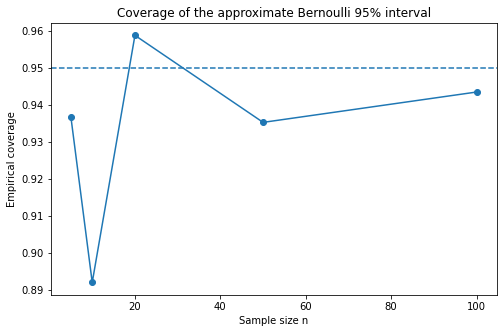

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, coverage_results, marker="o")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Sample size n")
plt.ylabel("Empirical coverage")
plt.title("Coverage of the approximate Bernoulli 95% interval")
plt.show()

The interval uses a large-sample Normal approximation. Small $n$ can therefore produce coverage noticeably different from 95%.

## 5.2 The interval $\bar X \pm S/\sqrt n$

Textbook Exercise 6.3.22 asks us to study

$$
\left(
\bar X-\frac{S}{\sqrt n},
\;
\bar X+\frac{S}{\sqrt n}
\right)
$$

for Normal data.

This is only a one-standard-error interval, so its coverage should be much lower than 95%.

In [14]:
mu_true = 0.0
sigma_true = 1.0
num_trials = 50_000
sample_sizes = [5, 10, 100]

for n in sample_sizes:
    samples = rng.normal(mu_true, sigma_true, size=(num_trials, n))
    means = samples.mean(axis=1)
    s = samples.std(axis=1, ddof=1)

    lower = means - s / np.sqrt(n)
    upper = means + s / np.sqrt(n)

    coverage = ((lower <= mu_true) & (mu_true <= upper)).mean()
    print(f"n={n:3d} | empirical coverage={coverage:.4f}")

n=  5 | empirical coverage=0.6280
n= 10 | empirical coverage=0.6573
n=100 | empirical coverage=0.6806


This experiment helps interpret what “one standard error” actually means.

---

# 6. Power as a function of sample size

Textbook Exercise 6.3.20 asks for the minimum sample size required so that a two-sided z-test has at least 80% power when the true mean differs from the null by $0.5$.

Assume

$$
X_i\sim N(\mu,2),
$$

so $\sigma=\sqrt 2$, and test

$$
H_0:\mu=\mu_0
$$

at significance level $\alpha=0.05$.

In [15]:
alpha = 0.05
sigma = np.sqrt(2)
delta = 0.5

def two_sided_z_power(n, delta, sigma, alpha=0.05):
    shift = delta * np.sqrt(n) / sigma
    zcrit = norm.ppf(1 - alpha/2)

    right_tail = 1 - norm.cdf(zcrit - shift)
    left_tail = norm.cdf(-zcrit - shift)

    return right_tail + left_tail

n_values = np.arange(2, 401)
powers = np.array([two_sided_z_power(n, delta, sigma, alpha) for n in n_values])

n_min = n_values[np.where(powers >= 0.80)[0][0]]

print(f"Minimum n with power >= 0.80: {n_min}")
print(f"Power at n={n_min}: {two_sided_z_power(n_min, delta, sigma, alpha):.4f}")

Minimum n with power >= 0.80: 63
Power at n=63: 0.8013


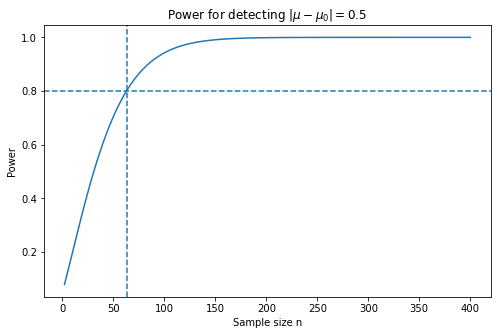

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(n_values, powers)
plt.axhline(0.80, linestyle="--")
plt.axvline(n_min, linestyle="--")
plt.xlabel("Sample size n")
plt.ylabel("Power")
plt.title(r"Power for detecting $|\mu-\mu_0|=0.5$")
plt.show()

The relationship is

$$
n\uparrow
\quad\Rightarrow\quad
\operatorname{SE}(\bar X)\downarrow
\quad\Rightarrow\quad
\text{fixed alternatives become easier to detect}.
$$

---

# 7. Sample-size planning from a target confidence-interval length

Textbook Exercise 6.3.19 asks for a 95% confidence interval for $\mu$ whose total length is at most 1, with a conservative upper bound $\sigma\le 5$.

Using the large-sample approximation,

$$
\bar X
\pm
z_{0.975}\frac{\sigma}{\sqrt n},
$$

the total length is

$$
2z_{0.975}\frac{\sigma}{\sqrt n}.
$$

In [17]:
sigma_upper = 5.0
target_length = 1.0
z = norm.ppf(0.975)

n_required = math.ceil((2 * z * sigma_upper / target_length)**2)

print(f"Required sample size: n = {n_required}")
print(f"Conservative interval length ≈ {2*z*sigma_upper/np.sqrt(n_required):.4f}")

Required sample size: n = 385
Conservative interval length ≈ 0.9989


This is an example of designing the sampling study before collecting the data.

---

# 8. Bootstrap: estimating a sampling distribution computationally

The bootstrap replaces the unknown population distribution by the empirical distribution of the observed sample.

Sampling from the empirical distribution is equivalent to sampling the observed values **with replacement**.

We use a self-contained dataset so that this notebook does not depend on data from textbook exercises that were not included in the screenshots.

In [18]:
data = np.array([
    -2.0, -0.2, -5.2, -3.5, -3.9,
    -0.6, -4.3, -1.7, -9.5,  1.6,
    -2.9,  0.9, -1.0, -2.0,  3.0
])

print(f"n = {len(data)}")
print(f"Sample mean   = {data.mean():.4f}")
print(f"Sample median = {np.median(data):.4f}")

n = 15
Sample mean   = -2.0867
Sample median = -2.0000


## 8.1 Bootstrap standard error of the median

In [19]:
def bootstrap_statistic(data, statistic, m=10_000, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    n = len(data)
    resamples = rng.choice(data, size=(m, n), replace=True)
    return np.apply_along_axis(statistic, 1, resamples)

boot_median = bootstrap_statistic(data, np.median, m=20_000, rng=rng)

print(f"Bootstrap mean of medians = {boot_median.mean():.4f}")
print(f"Bootstrap SE of median    = {boot_median.std(ddof=1):.4f}")

Bootstrap mean of medians = -1.9370
Bootstrap SE of median    = 0.8349


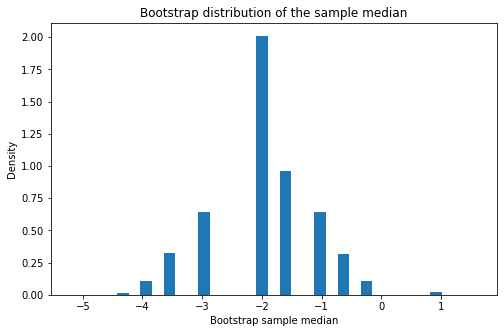

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(boot_median, bins=35, density=True)
plt.xlabel("Bootstrap sample median")
plt.ylabel("Density")
plt.title("Bootstrap distribution of the sample median")
plt.show()

The bootstrap approximates the sampling distribution without requiring an analytical formula for the median.

---

# 9. Mean versus median under outliers

The mean can be strongly influenced by extreme observations, while the median is more robust.

In [21]:
clean_data = rng.normal(0, 1, size=30)
outlier_data = clean_data.copy()
outlier_data[0] = 15.0

print("Clean data")
print(f"Mean   = {clean_data.mean():.4f}")
print(f"Median = {np.median(clean_data):.4f}")

print("\nWith one extreme outlier")
print(f"Mean   = {outlier_data.mean():.4f}")
print(f"Median = {np.median(outlier_data):.4f}")

Clean data
Mean   = -0.0971
Median = -0.1549

With one extreme outlier
Mean   = 0.3863
Median = -0.1549


Now bootstrap both estimators on the contaminated dataset.

In [22]:
boot_mean = bootstrap_statistic(outlier_data, np.mean, m=20_000, rng=rng)
boot_median = bootstrap_statistic(outlier_data, np.median, m=20_000, rng=rng)

print(f"Bootstrap SE of mean   = {boot_mean.std(ddof=1):.4f}")
print(f"Bootstrap SE of median = {boot_median.std(ddof=1):.4f}")

Bootstrap SE of mean   = 0.5207
Bootstrap SE of median = 0.3099


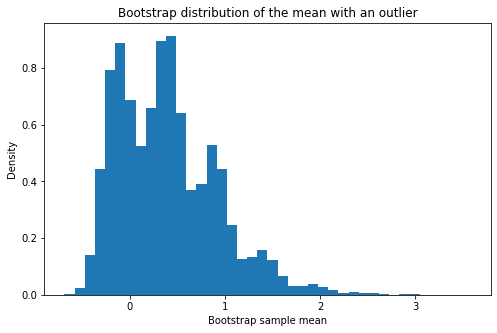

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(boot_mean, bins=40, density=True)
plt.xlabel("Bootstrap sample mean")
plt.ylabel("Density")
plt.title("Bootstrap distribution of the mean with an outlier")
plt.show()

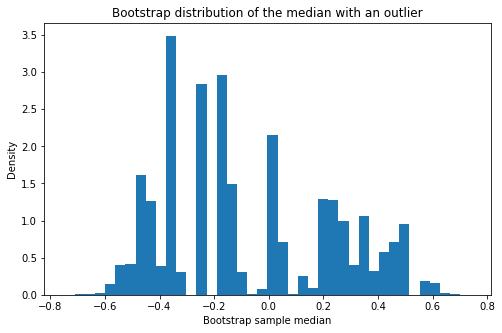

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(boot_median, bins=40, density=True)
plt.xlabel("Bootstrap sample median")
plt.ylabel("Density")
plt.title("Bootstrap distribution of the median with an outlier")
plt.show()

This experiment illustrates both robustness and sampling variability.

---

# 10. Bootstrap confidence intervals

We compare:

1. a classical t confidence interval;
2. a bootstrap percentile interval.

This is a simplified version of the broader comparisons suggested in the textbook's bootstrap exercises.

In [25]:
data_ci = rng.normal(loc=2.0, scale=3.0, size=40)

n = len(data_ci)
xbar = data_ci.mean()
s = data_ci.std(ddof=1)

# Classical 95% t interval
tcrit = t.ppf(0.975, df=n-1)
t_interval = (
    xbar - tcrit * s / np.sqrt(n),
    xbar + tcrit * s / np.sqrt(n)
)

# Bootstrap percentile interval
boot_means = bootstrap_statistic(data_ci, np.mean, m=20_000, rng=rng)
bootstrap_interval = tuple(np.quantile(boot_means, [0.025, 0.975]))

print(f"Sample mean = {xbar:.4f}")
print(f"95% t interval           = ({t_interval[0]:.4f}, {t_interval[1]:.4f})")
print(f"95% bootstrap percentile = ({bootstrap_interval[0]:.4f}, {bootstrap_interval[1]:.4f})")

Sample mean = 1.8878
95% t interval           = (0.9685, 2.8071)
95% bootstrap percentile = (1.0124, 2.7596)


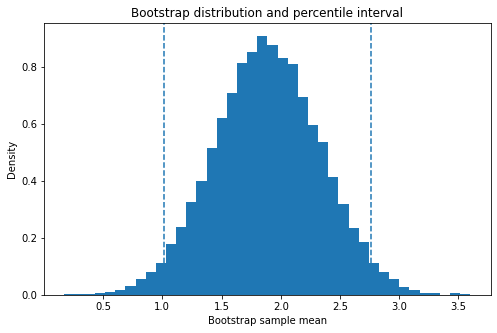

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(boot_means, bins=40, density=True)
plt.axvline(bootstrap_interval[0], linestyle="--")
plt.axvline(bootstrap_interval[1], linestyle="--")
plt.xlabel("Bootstrap sample mean")
plt.ylabel("Density")
plt.title("Bootstrap distribution and percentile interval")
plt.show()

For approximately Normal data and a smooth estimator like the mean, the two intervals will often be fairly similar.

The bootstrap becomes especially useful when the estimator's analytical sampling distribution is difficult to derive.

---

# 11. Optional extension: empirical MSE decomposition

We can directly verify

$$
\operatorname{MSE}(T)
=
\operatorname{Var}(T)
+
\operatorname{Bias}(T)^2
$$

with simulation.

In [27]:
truth = 5.0
num_trials = 100_000

samples = rng.normal(loc=truth, scale=2.0, size=(num_trials, 20))

# Intentionally biased estimator
T = samples.mean(axis=1) + 0.5

bias = T.mean() - truth
variance = T.var(ddof=0)
mse = np.mean((T - truth)**2)

print(f"Bias              = {bias:.6f}")
print(f"Variance          = {variance:.6f}")
print(f"Bias^2 + Variance = {bias**2 + variance:.6f}")
print(f"Direct MSE        = {mse:.6f}")

Bias              = 0.499678
Variance          = 0.202054
Bias^2 + Variance = 0.451732
Direct MSE        = 0.451732


The two MSE calculations should agree up to simulation error.

---

# 12. Key computational takeaways

### Likelihood and optimization

- Likelihood functions can be asymmetric or multimodal.
- Numerical visualization helps reveal likelihood geometry.
- Log-likelihood preserves the optimizer while converting products into sums.
- MLE is fundamentally an optimization problem.

### Estimator behavior

- Unbiasedness and maximum likelihood are different criteria.
- MSE combines variance and squared bias.
- Standard error is the standard deviation of an estimator's sampling distribution.
- For the sample mean, SE shrinks like $1/\sqrt n$.

### Confidence and testing

- Approximate confidence intervals can have poor finite-sample coverage.
- z-tests become more sensitive as $n$ grows.
- Power depends on effect size, noise, significance level, and sample size.
- Sample-size planning chooses $n$ to achieve desired precision or power.

### Bootstrap

- The empirical distribution substitutes for the unknown population distribution.
- Resampling with replacement approximates repeated sampling.
- Bootstrap is especially useful when analytical sampling distributions are difficult.
- It is also useful for studying robust estimators such as the median.

---

## Suggested later ML connections

- negative log-likelihood losses in PyTorch;
- gradient-based MLE;
- logistic regression as Bernoulli maximum likelihood;
- softmax cross-entropy as categorical negative log-likelihood;
- bootstrap uncertainty for model metrics.